# Evaluation — Final Models

Carica i modelli pre-addestrati, valuta R² su test set, genera scatter plot e feature importance.

**Dati richiesti:** `../data/ultimate_train.csv` e `../data/ultimate_test.csv`
**Modelli richiesti:** `../models/final/*.pth`

In [25]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import sklearn.metrics
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [ ]:
df = pd.read_csv('../data/ultimate_train.csv')
df_test = pd.read_csv('../data/ultimate_test.csv')
print(f"Train: {len(df)}, Test: {len(df_test)}")

Train: 979414, Test: 244854


## Feature Engineering

In [27]:
def engineer_features(df_in):
    d = df_in.copy()
    d['eucl_dist'] = np.sqrt(
        (d['destination_lat'] - d['origin_lat'])**2 +
        (d['destination_lon'] - d['origin_lon'])**2
    )
    d['svolte_per_km'] = d['svolte_totali'] / d['osrm_distance']
    d['incroci_per_km'] = d['incroci_totali'] / d['osrm_distance']
    d['pickup_hour_sin'] = np.sin(2 * np.pi * d['pickup_hour'] / 24)
    d['pickup_hour_cos'] = np.cos(2 * np.pi * d['pickup_hour'] / 24)
    d['pickup_day_sin'] = np.sin(2 * np.pi * d['pickup_dayofweek'] / 7)
    d['pickup_day_cos'] = np.cos(2 * np.pi * d['pickup_dayofweek'] / 7)
    d['pickup_month_sin'] = np.sin(2 * np.pi * d['pickup_month'] / 12)
    d['pickup_month_cos'] = np.cos(2 * np.pi * d['pickup_month'] / 12)
    d['gap'] = d['trip_duration'] - d['osrm_eta']
    return d

df = engineer_features(df)
df_test = engineer_features(df_test)

In [28]:
FEATURES = [
    "origin_lat", "origin_lon", "destination_lat", "destination_lon",
    "osrm_eta", "osrm_distance", "svolte_totali", "svolte_sinistra",
    "incroci_totali", "incroci_complessi", "nodi_attraversati", "eucl_dist",
    "svolte_per_km", "incroci_per_km",
    "pickup_hour_sin", "pickup_hour_cos",
    "pickup_day_sin", "pickup_day_cos",
    "pickup_month_sin", "pickup_month_cos",
]
print(f"Feature totali: {len(FEATURES)}")

Feature totali: 20


## Split e normalizzazione

In [29]:
df = df.dropna(subset=FEATURES + ['gap'])
q_low = df['gap'].quantile(0.01)
q_high = df['gap'].quantile(0.99)
df = df[(df['gap'] >= q_low) & (df['gap'] <= q_high)]

df_train, df_val = train_test_split(df, test_size=0.2, random_state=42)
print(f"Train: {len(df_train)}, Val: {len(df_val)}")

df_test = df_test.dropna(subset=FEATURES + ['gap'])
df_test = df_test[(df_test['gap'] >= q_low) & (df_test['gap'] <= q_high)]
print(f"Test: {len(df_test)}")

X_train_full = torch.tensor(df_train[FEATURES].to_numpy(dtype=np.float32))
means = X_train_full.mean(dim=0, keepdims=True)
stds = X_train_full.std(dim=0, keepdims=True)
stds[stds == 0] = 1.0

y_train_full = torch.tensor(df_train['gap'].to_numpy(dtype=np.float32)).view(-1, 1)
y_means = y_train_full.mean(dim=0, keepdims=True)
y_stds = y_train_full.std(dim=0, keepdims=True)

print(f"y_mean: {y_means.item():.4f}, y_std: {y_stds.item():.4f}")

Train: 765524, Val: 191381
Test: 239300
y_mean: 328.4504, y_std: 290.8050


## Caricamento modelli

In [ ]:
import sys
sys.path.append('../phase3_training')
from models import (
    ResMLP, DeepResMLP, CustomModel1,
    MultiBranchModel, MultiBranchResNet, ResidualBlock
)

def build_model_mlp_v2():
    return nn.Sequential(
        nn.Linear(20, 200), nn.BatchNorm1d(200), nn.ReLU(), nn.Dropout(0.2),
        nn.Linear(200, 200), nn.BatchNorm1d(200), nn.ReLU(), nn.Dropout(0.2),
        nn.Linear(200, 1),
    )

def build_custom_model1():
    return CustomModel1(20)

def build_model_resmlp():
    return ResMLP(20)

def build_model_multibranch():
    return MultiBranchModel(20)

def build_model_multibranch_resnet():
    return MultiBranchResNet(20)

def build_model_deep_resmlp():
    return DeepResMLP(20)

MODEL_REGISTRY = {
    "model_mlp_v2":             ("../models/final/model_mlp_v2.pth",             build_model_mlp_v2),
    "customModel1":             ("../models/final/customModel1.pth",             build_custom_model1),
    "model_resmlp":             ("../models/final/model_resmlp.pth",             build_model_resmlp),
    "model_multibranch":        ("../models/final/model_multibranch.pth",        build_model_multibranch),
    "model_multibranch_resnet": ("../models/final/model_multibranch_resnet.pth", build_model_multibranch_resnet),
    "model_deep_resmlp":        ("../models/final/model_deep_resmlp.pth",        build_model_deep_resmlp),
}

print(f"Modelli: {list(MODEL_REGISTRY.keys())}")

Modelli: ['model_mlp_v2', 'customModel1', 'model_resmlp', 'model_multibranch', 'model_multibranch_resnet', 'model_deep_resmlp']


## Valutazione

In [31]:
class ModelWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, predict_fn=None):
        self.predict_fn = predict_fn
    def fit(self, X, y):
        return self
    def predict(self, X):
        return self.predict_fn(X)

@torch.no_grad()
def predict(model, X_tensor):
    model.eval()
    return model(X_tensor).cpu().numpy().ravel()

def plot_predictions(y_true, y_pred, model_name, ax):
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.scatter(y_true, y_pred, alpha=0.15, s=1, rasterized=True)
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfetta')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Gap reale (s)'); ax.set_ylabel('Gap predetto (s)')
    ax.set_title(model_name); ax.legend(); ax.set_aspect('equal')

def plot_permutation_importance(importances, feature_names, model_name, ax):
    mean = importances['importances_mean']
    std = importances['importances_std']
    order = np.argsort(mean)
    ax.barh(range(len(mean)), mean[order], xerr=std[order], capsize=3)
    ax.set_yticks(range(len(mean)))
    ax.set_yticklabels([feature_names[i] for i in order], fontsize=8)
    ax.set_xlabel('Calo di R² (permutation importance)')
    ax.set_title(f'{model_name} — Feature Importance')


  model_mlp_v2
  R² gap: 0.5148
  MAE gap:   146.3s
  RMSE gap:  202.4s
  MedAE gap: 110.1s
  Max err:   1447.2s
  R² trip:   0.7538
  MAE trip:  146.3s
  RMSE trip: 202.4s
  MAPE trip: 31.4%
  Calcolo permutation importance su 20000 campioni...


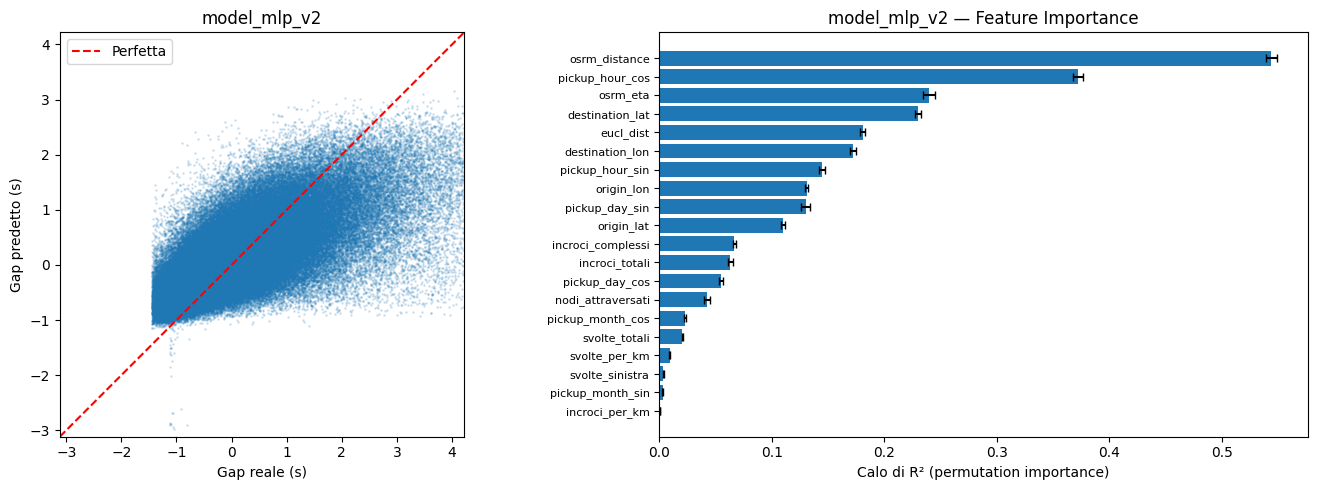


  customModel1
  R² gap: 0.5268
  MAE gap:   142.0s
  RMSE gap:  199.9s
  MedAE gap: 103.5s
  Max err:   1460.2s
  R² trip:   0.7599
  MAE trip:  142.0s
  RMSE trip: 199.9s
  MAPE trip: 30.1%
  Calcolo permutation importance su 20000 campioni...


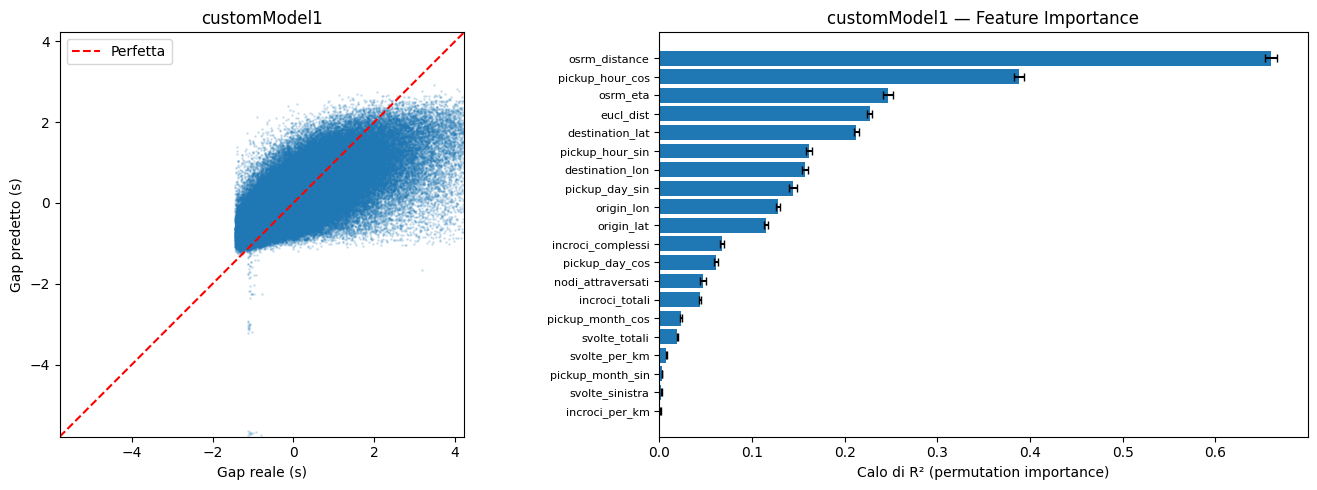


  model_resmlp
  R² gap: 0.5391
  MAE gap:   140.1s
  RMSE gap:  197.3s
  MedAE gap: 102.2s
  Max err:   1702.6s
  R² trip:   0.7661
  MAE trip:  140.1s
  RMSE trip: 197.3s
  MAPE trip: 30.5%
  Calcolo permutation importance su 20000 campioni...


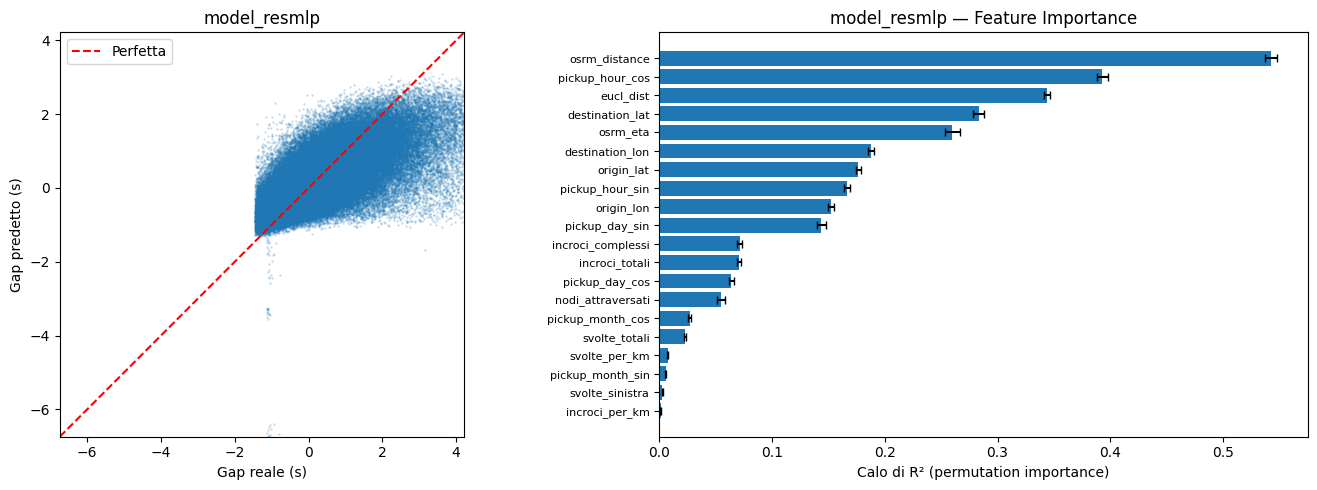


  model_multibranch
  R² gap: 0.5035
  MAE gap:   147.9s
  RMSE gap:  204.8s
  MedAE gap: 111.3s
  Max err:   2272.2s
  R² trip:   0.7481
  MAE trip:  147.9s
  RMSE trip: 204.8s
  MAPE trip: 34.2%
  Calcolo permutation importance su 20000 campioni...


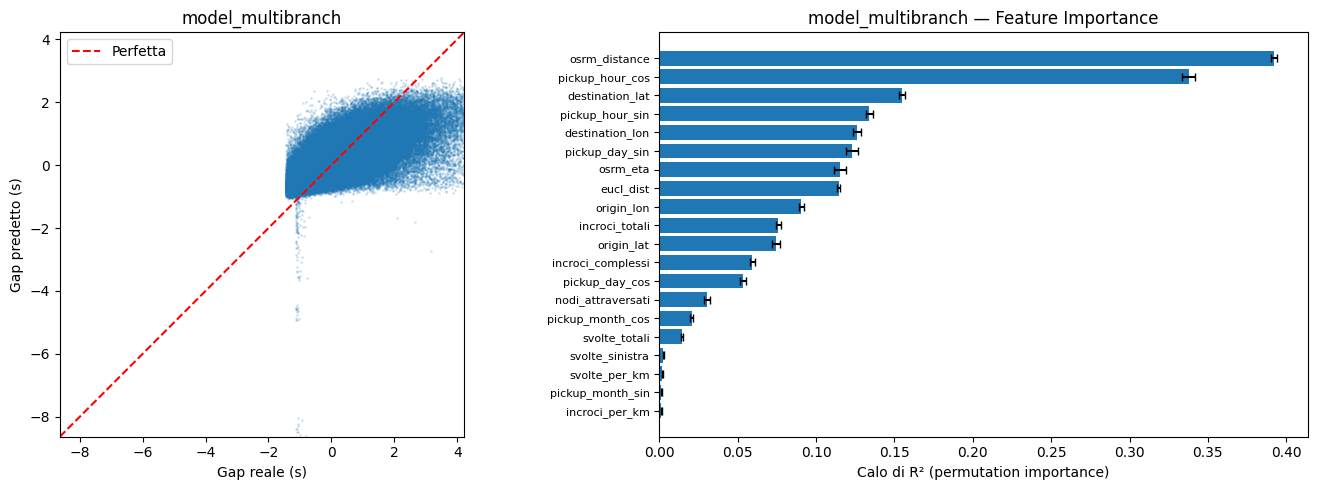


  model_multibranch_resnet
  R² gap: 0.5149
  MAE gap:   144.8s
  RMSE gap:  202.4s
  MedAE gap: 107.3s
  Max err:   1435.0s
  R² trip:   0.7538
  MAE trip:  144.8s
  RMSE trip: 202.4s
  MAPE trip: 30.9%
  Calcolo permutation importance su 20000 campioni...


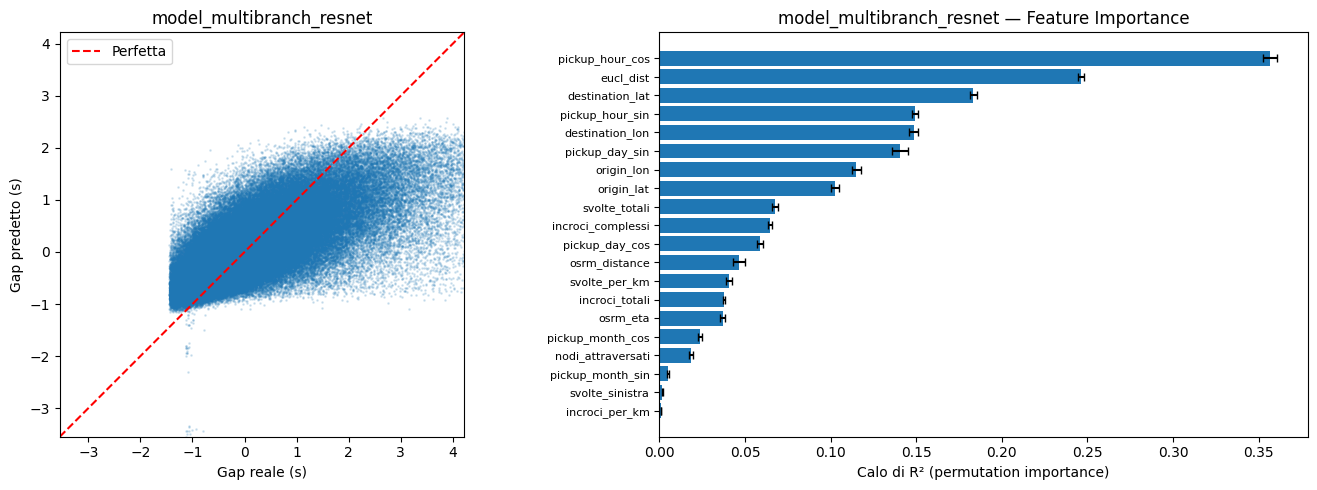


  model_deep_resmlp
  R² gap: 0.5575
  MAE gap:   136.9s
  RMSE gap:  193.3s
  MedAE gap: 99.8s
  Max err:   1752.4s
  R² trip:   0.7755
  MAE trip:  136.9s
  RMSE trip: 193.3s
  MAPE trip: 29.9%
  Calcolo permutation importance su 20000 campioni...


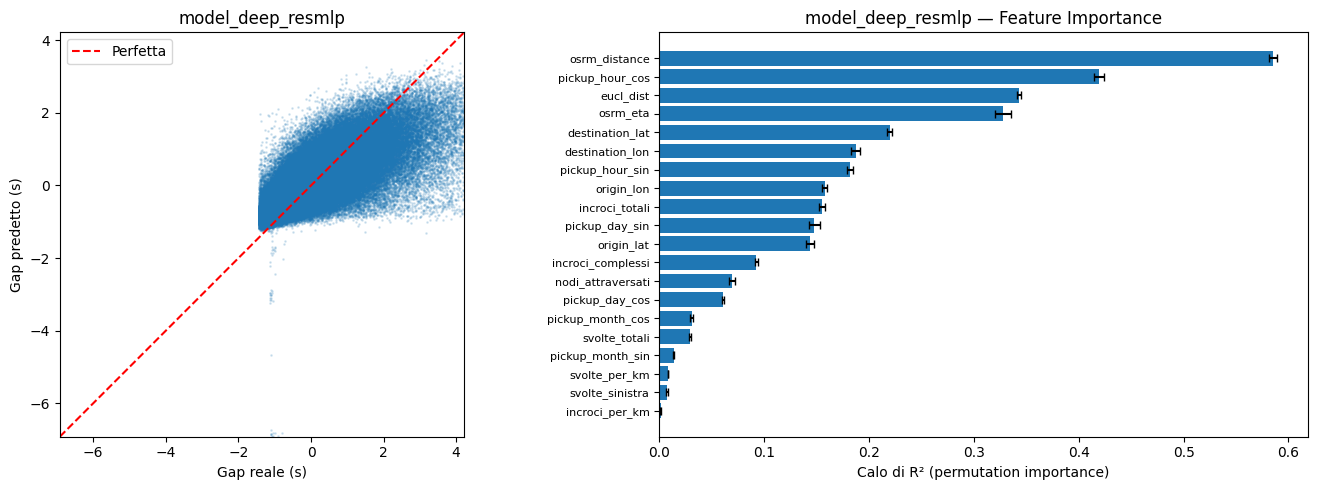


  RIEPILOGO
  Modello                             R²     MAE    RMSE   R² trip    MAPE
  ----------------------------------------------------------------------
  model_deep_resmlp               0.5575  137s  193s  0.7755  29.9%
  model_resmlp                    0.5391  140s  197s  0.7661  30.5%
  customModel1                    0.5268  142s  200s  0.7599  30.1%
  model_multibranch_resnet        0.5149  145s  202s  0.7538  30.9%
  model_mlp_v2                    0.5148  146s  202s  0.7538  31.4%
  model_multibranch               0.5035  148s  205s  0.7481  34.2%


In [32]:
# Prepara test set
osrm_eta_test = df_test['osrm_eta'].to_numpy(dtype=np.float32)
X_test_t = torch.tensor(df_test[FEATURES].to_numpy(dtype=np.float32))
X_test_t = (X_test_t - means) / stds
y_test = torch.tensor(df_test['gap'].to_numpy(dtype=np.float32)).view(-1, 1)
y_test = (y_test - y_means) / y_stds
test_loader = DataLoader(TensorDataset(X_test_t, y_test), batch_size=1024)

results = {}
for name, (path, build_fn) in MODEL_REGISTRY.items():
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    model = build_fn()
    state = torch.load(path, map_location=device, weights_only=True)
    model.load_state_dict(state)
    model.to(device)
    y_pred_norm = predict(model, X_test_t.to(device))
    y_true_norm = y_test.numpy().ravel()
    r2 = sklearn.metrics.r2_score(y_true_norm, y_pred_norm)
    y_pred = y_pred_norm * y_stds.item() + y_means.item()
    y_true = y_true_norm * y_stds.item() + y_means.item()
    mae = sklearn.metrics.mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(sklearn.metrics.mean_squared_error(y_true, y_pred))
    medae = sklearn.metrics.median_absolute_error(y_true, y_pred)
    max_err = np.max(np.abs(y_true - y_pred))
    trip_true = osrm_eta_test + y_true
    trip_pred = osrm_eta_test + y_pred
    r2_trip = sklearn.metrics.r2_score(trip_true, trip_pred)
    mae_trip = sklearn.metrics.mean_absolute_error(trip_true, trip_pred)
    rmse_trip = np.sqrt(sklearn.metrics.mean_squared_error(trip_true, trip_pred))
    mape_trip = np.mean(np.abs((trip_true - trip_pred) / np.maximum(trip_true, 1))) * 100
    print(f"  R² gap: {r2:.4f}")
    print(f"  MAE gap:   {mae:.1f}s")
    print(f"  RMSE gap:  {rmse:.1f}s")
    print(f"  MedAE gap: {medae:.1f}s")
    print(f"  Max err:   {max_err:.1f}s")
    print(f"  R² trip:   {r2_trip:.4f}")
    print(f"  MAE trip:  {mae_trip:.1f}s")
    print(f"  RMSE trip: {rmse_trip:.1f}s")
    print(f"  MAPE trip: {mape_trip:.1f}%")
    results[name] = {'r2': r2, 'mae': mae, 'rmse': rmse,
                     'r2_trip': r2_trip, 'mae_trip': mae_trip, 'mape': mape_trip}
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_predictions(y_true_norm, y_pred_norm, name, axes[0])
    # Permutation importance
    print("  Calcolo permutation importance su 20000 campioni...")
    X_sample = X_test_t[:20000]
    y_sample = y_test[:20000]
    wrapper = ModelWrapper(lambda X: predict(model, torch.tensor(X, dtype=torch.float32).to(device)))
    result = permutation_importance(
        wrapper, X_sample.numpy(), y_sample.numpy(),
        n_repeats=5, scoring='r2', random_state=42, n_jobs=2
    )
    plot_permutation_importance(result, FEATURES, name, axes[1])
    plt.tight_layout()
    plt.show()
print("\n" + "="*60)
print("  RIEPILOGO")
print(f"  {'Modello':30s}  {'R²':>6s}  {'MAE':>6s}  {'RMSE':>6s}  {'R² trip':>8s}  {'MAPE':>6s}")
print("  " + "-"*70)
print("="*60)
for name, res in sorted(results.items(), key=lambda x: -x[1]['r2']):
    print(f"  {name:30s}  {res['r2']:.4f}  {res['mae']:.0f}s  {res['rmse']:.0f}s  {res['r2_trip']:.4f}  {res['mape']:.1f}%")